In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, roc_auc_score)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv(r"C:\Users\Acer\Downloads\hotel_booking.csv\hotel_booking.csv")
print(f"Shape: {df.shape}")
print(df.head())
print(df.describe())

Shape: (119390, 36)
          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  customer_type  \
0                        0                     0       2  ...   

          Missing Count  Percentage
company          112593   94.306893
agent             16340   13.686238
country             488    0.408744
children              4    0.003350
is_canceled
0    75166
1    44224
Name: count, dtype: int64
Cancellation rate: 37.0%


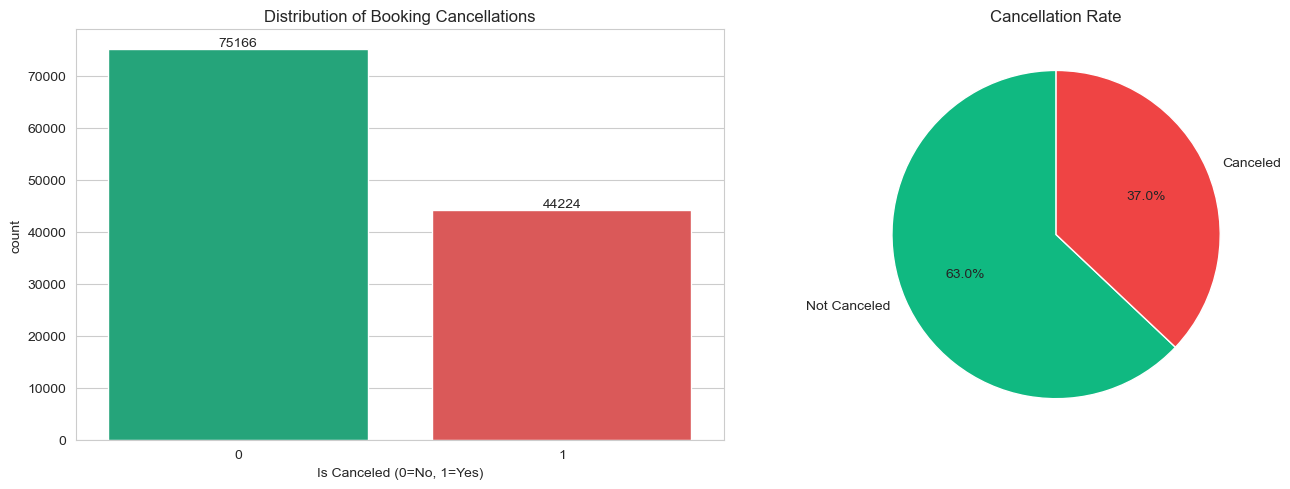

In [3]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage': df.isnull().sum() / len(df) * 100
})
print(missing[missing['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

print(df['is_canceled'].value_counts())
print(f"Cancellation rate: {df['is_canceled'].mean()*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x='is_canceled', ax=axes[0], palette=['#10b981', '#ef4444'])
axes[0].set_title('Distribution of Booking Cancellations')
axes[0].set_xlabel('Is Canceled (0=No, 1=Yes)')
for container in axes[0].containers:
    axes[0].bar_label(container)

axes[1].pie(df['is_canceled'].value_counts(), labels=['Not Canceled', 'Canceled'],
            autopct='%1.1f%%', colors=['#10b981', '#ef4444'], startangle=90)
axes[1].set_title('Cancellation Rate')
plt.tight_layout()
plt.show()

Shape after cleaning: (119390, 36)
lead_time: removed 3,005 outliers
adr: removed 3,768 outliers


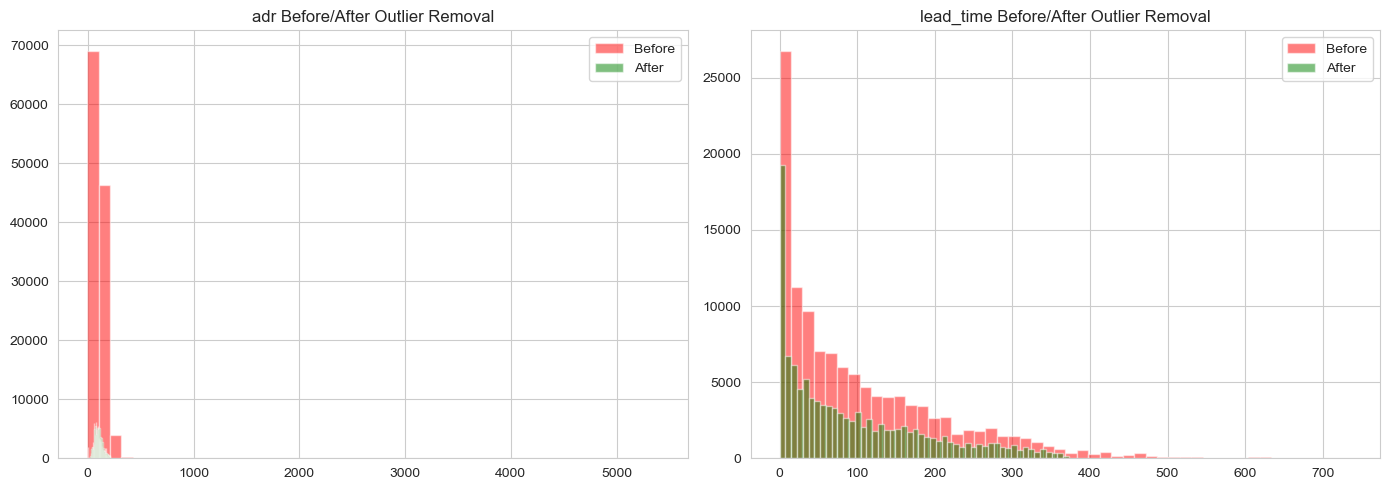

In [4]:
df_clean = df.copy()

df_clean['children'].fillna(0, inplace=True)
df_clean['country'].fillna('Unknown', inplace=True)
df_clean['agent'].fillna(0, inplace=True)
df_clean['company'].fillna(0, inplace=True)

df_clean.drop_duplicates(inplace=True)
print(f"Shape after cleaning: {df_clean.shape}")

def remove_outliers_iqr(data, column):
    Q1, Q3 = data[column].quantile(0.25), data[column].quantile(0.75)
    IQR = Q3 - Q1
    before = len(data)
    data = data[(data[column] >= Q1 - 1.5*IQR) & (data[column] <= Q3 + 1.5*IQR)]
    print(f"{column}: removed {before - len(data):,} outliers")
    return data

for col in ['lead_time', 'adr']:
    df_clean = remove_outliers_iqr(df_clean, col)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col in zip(axes, ['adr', 'lead_time']):
    ax.hist(df[col], bins=50, alpha=0.5, label='Before', color='red')
    ax.hist(df_clean[col], bins=50, alpha=0.5, label='After', color='green')
    ax.set_title(f'{col} Before/After Outlier Removal')
    ax.legend()
plt.tight_layout()
plt.show()

Top correlations with cancellation:
is_canceled                 1.000000
lead_time                   0.288038
previous_cancellations      0.113101
adr                         0.073889
adults                      0.060348
days_in_waiting_list        0.057564
total_guests                0.048119
stays_in_week_nights        0.028000
total_stays                 0.022628
arrival_date_week_number    0.004751
stays_in_weekend_nights     0.004438
Name: is_canceled, dtype: float64


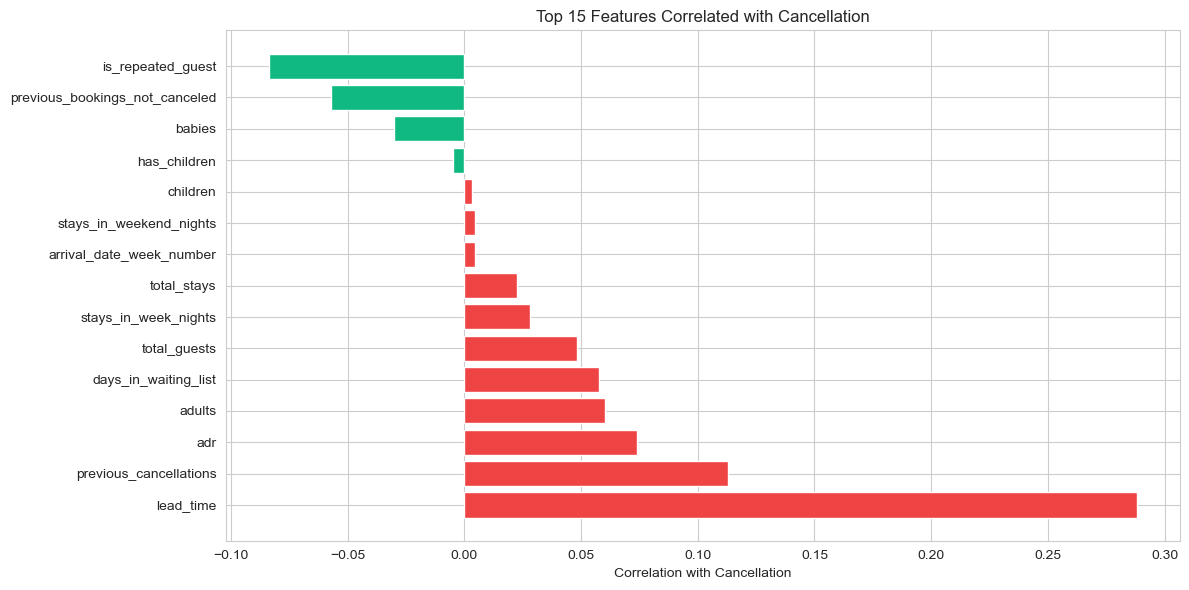

In [5]:
df_clean['total_stays'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean['total_guests'] = df_clean['adults'] + df_clean['children'] + df_clean['babies']
df_clean['has_children'] = (df_clean['children'] > 0).astype(int)

features_to_use = [
    'hotel', 'lead_time', 'arrival_date_month', 'arrival_date_week_number',
    'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
    'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
    'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled',
    'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type',
    'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests', 'total_stays', 'total_guests', 'has_children'
]

X = df_clean[features_to_use]
y = df_clean['is_canceled']

numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
correlations = df_clean[numerical_features + ['is_canceled']].corr()['is_canceled'].sort_values(ascending=False)
print("Top correlations with cancellation:")
print(correlations.head(11))

top_features = correlations[1:16]
colors = ['#ef4444' if x > 0 else '#10b981' for x in top_features.values]
plt.barh(range(len(top_features)), top_features.values, color=colors)
plt.yticks(range(len(top_features)), top_features.index)
plt.xlabel('Correlation with Cancellation')
plt.title('Top 15 Features Correlated with Cancellation')
plt.tight_layout()
plt.show()

In [6]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {X_train.shape[1]}")
print(f"Cancellation rate — Train: {y_train.mean()*100:.2f}% | Test: {y_test.mean()*100:.2f}%")

Train: 90,093 | Test: 22,524 | Features: 245
Cancellation rate — Train: 36.19% | Test: 36.19%


Accuracy:  0.8179
Precision: 0.8118
Recall:    0.6468
F1-Score:  0.7200
ROC-AUC:   0.8945
              precision    recall  f1-score   support

Not Canceled       0.82      0.91      0.87     14373
    Canceled       0.81      0.65      0.72      8151

    accuracy                           0.82     22524
   macro avg       0.82      0.78      0.79     22524
weighted avg       0.82      0.82      0.81     22524



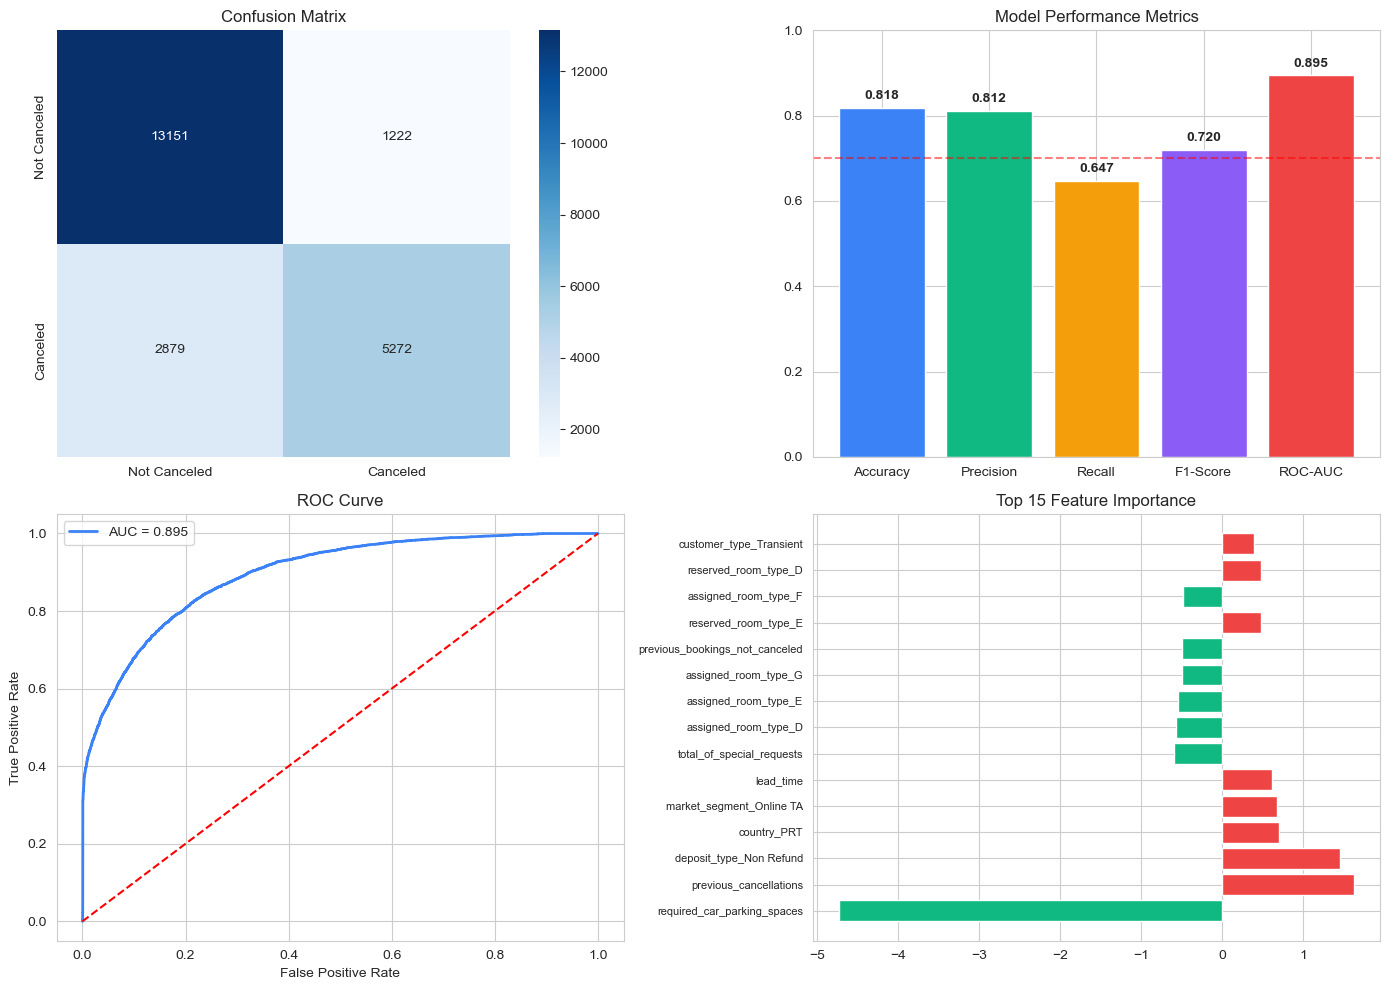

In [7]:
log_reg = LogisticRegression(solver='liblinear', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")
print(classification_report(y_test, y_pred, target_names=['Not Canceled', 'Canceled']))

cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['Not Canceled', 'Canceled'],
            yticklabels=['Not Canceled', 'Canceled'])
axes[0, 0].set_title('Confusion Matrix')

metrics_values = [accuracy, precision, recall, f1, roc_auc]
metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
axes[0, 1].bar(metrics_names, metrics_values, color=['#3b82f6','#10b981','#f59e0b','#8b5cf6','#ef4444'])
axes[0, 1].set_ylim(0, 1)
axes[0, 1].axhline(y=0.7, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(metrics_values):
    axes[0, 1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')
axes[0, 1].set_title('Model Performance Metrics')

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1, 0].plot(fpr, tpr, color='#3b82f6', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1, 0].plot([0, 1], [0, 1], 'r--')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()

feature_imp = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False).head(15)

colors_imp = ['#ef4444' if x > 0 else '#10b981' for x in feature_imp['coefficient']]
axes[1, 1].barh(range(len(feature_imp)), feature_imp['coefficient'], color=colors_imp)
axes[1, 1].set_yticks(range(len(feature_imp)))
axes[1, 1].set_yticklabels(feature_imp['feature'], fontsize=8)
axes[1, 1].set_title('Top 15 Feature Importance')

plt.tight_layout()
plt.show()

In [9]:
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=5, scoring='accuracy')
print(f"CV Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")
print(f"Fold scores: {cv_scores}")

joblib.dump(log_reg, 'logistic_regression_modell.pkl')
joblib.dump(scaler, 'scalerr.pkl')
print("Saved")

CV Mean: 0.8142 | Std: 0.0011
Fold scores: [0.81430712 0.81225373 0.81425162 0.81479631 0.81557332]
Saved
